# **M3 Integrated Analysis and Synergy Phase: Unsupervised Machine Learning for Grant "Era" Analysis**
**US Government Grant Opportunities Dataset**

By: Anna Baldzikowski


BA820 A1, Team 11

##**Domain Question:**

How have grant opportunity characteristics (agency, estimated funding, year posted, eligibility, category) evolved over time, and do distinct policy-era archetypes emerge in modern federal grantmaking?

*Based on and modified from question 2 in M1*

## **Changes to this notebook since M2:**



1.   Not showing EDA here, as to clean up notebook (all EDA in M2 notebook on GitHub is still relevant)

2.   In data cleaning-- **Instead of dropping NA rows in estimated_funding, I now replaced them with zeros.** This is more ideal for a comprehensive look at my data and clusters, as this way I do not have to drop 1315 rows of 2000. This decision came about from communicating with my team and finding out that my teammates found this method to be beneficial in M2-- so this is a form of synergy that developed in M3.

3. **I switched my k-means to k-prototypes in this analysis.** From Sambisha's findings that k-modes worked on her categorical data, I realized that k-prototypes with my mixed (numeric/categorical) data is a mathematically better way to analyze my data rather than one-hot encoding the categorical features. This represents another form of synergy.

4. Added a final portion where I compare my findings to my teammates and **gain deeper insights as I combine our findings.**


Throughout this notebook, changes (like keeping NAs and turning them to zeros, and my choice to use k-prototypes), are in *italics*

## **Upload data to Colab**

In [21]:
import pandas as pd

grants = pd.read_csv(
    "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-10-03/grants.csv"
)

details = pd.read_csv(
    "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-10-03/grant_opportunity_details.csv"
)


/tmp/ipython-input-1792275738.py:3: DtypeWarning: Columns (6,8,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  grants = pd.read_csv(


## **Dataset Preliminary EDA: Pre-Clustering**

### **1. Dataset Structure and Coverage**

**Grants Table:**

In [22]:
grants.shape

(74669, 17)

In [23]:
grants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74669 entries, 0 to 74668
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   opportunity_id                  74669 non-null  int64  
 1   opportunity_number              74669 non-null  object 
 2   opportunity_title               74669 non-null  object 
 3   agency_code                     74626 non-null  object 
 4   agency_name                     74625 non-null  object 
 5   estimated_funding               53043 non-null  float64
 6   expected_number_of_awards       53371 non-null  object 
 7   grantor_contact                 74638 non-null  object 
 8   agency_contact_phone            668 non-null    object 
 9   agency_contact_email            73791 non-null  object 
 10  estimated_post_date             517 non-null    object 
 11  estimated_application_due_date  574 non-null    object 
 12  posted_date                     

**Details Table:**

In [24]:
details.shape

(2000, 68)

In [25]:
details.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 68 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   opportunity_id                                                       2000 non-null   int64  
 1   funding_opportunity_number                                           2000 non-null   object 
 2   funding_opportunity_title                                            2000 non-null   object 
 3   opportunity_category                                                 2000 non-null   object 
 4   opportunity_category_explanation                                     53 non-null     object 
 5   expected_number_of_awards                                            619 non-null    float64
 6   cost_sharing_or_matching_requirement                                 2000 non-null   bool   
 7   versio

In [26]:
# Merge the tables
merged = grants.merge(details, on='opportunity_id', how='inner')

print("Merged rows:", len(merged))

# Just create posted_year for checking temporal coverage
merged['posted_year'] = pd.to_datetime(merged['posted_date_y']).dt.year

print("\nYear range in merged data:")
print(merged['posted_year'].agg(['min', 'max', 'count']))

print("\nYear distribution:")
print(merged['posted_year'].value_counts().sort_index())

print("\nAgency distribution (top 10):")
print(merged['agency_name_y'].value_counts().head(10))

# Check category columns
category_cols = [col for col in merged.columns if col.startswith('category_')]
print("\nNumber of category columns:", len(category_cols))

# Check eligibility columns
eligibility_cols = [col for col in merged.columns if col.startswith('eligibility_')]
print("Number of eligibility columns:", len(eligibility_cols))

Merged rows: 2000

Year range in merged data:
min      2004
max      2023
count    2000
Name: posted_year, dtype: int64

Year distribution:
posted_year
2004       1
2007       2
2008       2
2009       9
2010       5
2011       7
2012       7
2013       3
2014       7
2015      17
2016      10
2017      10
2018      38
2019      28
2020     125
2021     306
2022     400
2023    1023
Name: count, dtype: int64

Agency distribution (top 10):
agency_name_y
National Institutes of Health                       967
National Science Foundation                         276
Department of Commerce                               45
Dept. of the Army -- USAMRAA                         44
NASA Headquarters                                    43
Agency for International Development                 42
Environmental Protection Agency                      40
Fish and Wildlife Service                            27
National Energy Technology Laboratory                25
Centers for Disease Control and Prevent

In [27]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 85 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   opportunity_id                                                       2000 non-null   int64  
 1   opportunity_number                                                   2000 non-null   object 
 2   opportunity_title                                                    2000 non-null   object 
 3   agency_code                                                          2000 non-null   object 
 4   agency_name_x                                                        2000 non-null   object 
 5   estimated_funding                                                    685 non-null    float64
 6   expected_number_of_awards_x                                          619 non-null    object 
 7   granto

**Analysis on merging tables:**
When selecting features to see if time-bound "eras" of funding emerge with unsupervised ML, I came to find that the Grants table did not include enough fruitful features to honor the question. The Grants table's features mainly capture administrative scale, not policy priorities. The Details table is needed to accurately evaluate if "eras" emerge, even though merging the tables makes the dataset smaller.


## **Unsupervised Machine Learning**

### **1. Preparing Data for Clustering: Feature Selection, Data Cleaning**


In [28]:
# Checking on posted_date_x vs posted_year
merged[['posted_date_x', 'posted_year']]

,posted_date_x,posted_year
0,2023-09-28,2023
1,2023-09-28,2023
2,2023-09-28,2023
3,2023-09-28,2023
4,2023-09-28,2023
...,...,...
1995,2008-07-22,2008
1996,2008-06-17,2008
1997,2007-11-28,2007
1998,2007-11-28,2007


*Changes since M2: Attempting k-prototypes to handle my mixed features- I recalled learning about this method briefly in class. Sambisha inspired my thinking about this, as she used k-modes on her categorical dataset.*

Features that will be used in unsupervised machine learning to see if time-bound "eras" are visible:


*   agency_name_x
*   estimated_funding
*   posted_year
*   eligibility
*   category

**Correlation matrix between my 2 numeric variables**

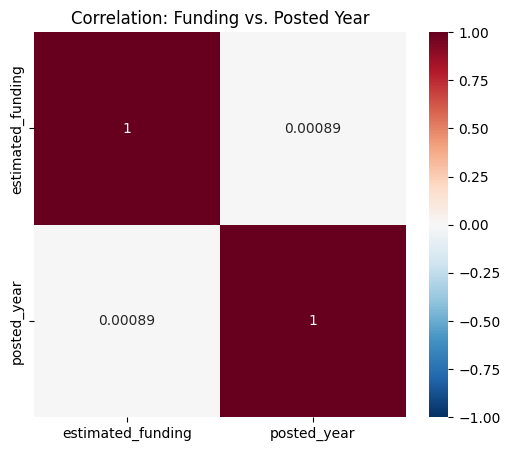

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select only the two numeric columns
# Use .dropna() because correlation cannot be calculated with missing values
numeric_data = merged[['estimated_funding', 'posted_year']].dropna()

# Calculate the correlation matrix
# This will result in a 2x2 table showing how Year and Funding relate
corr_matrix = numeric_data.corr()

# Plot the Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix,
            annot=True,      # Shows the correlation number
            cmap='RdBu_r',   # Red for positive, Blue for negative
            center=0,
            vmin=-1, vmax=1) # Set the scale from -1 to 1

plt.title('Correlation: Funding vs. Posted Year')
plt.show()

**Analysis of correlation matrix:** I am not going to run PCA, as

1. more than half of my features are categorical, so the distance-use of PCA wouldn't make sense.

2. My 2 numeric features (estimated_funding and posted_year) are not highly correlated- this makes sense intuitively as well.

In [30]:
# Check for missing values in merged_ml
print("Missing values in merged_ml:")
print(merged['estimated_funding'].isnull().sum())

Missing values in merged_ml:
1315


*Change since M2: instead of dropping the NAs, I am testing turning them into 0s. This way I can keep 1315 rows of information.*

In [31]:
merged['estimated_funding'] = merged['estimated_funding'].fillna(0)

###**2. Preprocessing: Normalization, Log Transform Funding, Compact Agencies, Select Columns**

In [32]:
# Checking for skewed estimated_funding (to see if it needs log transformation)
print("Estimated funding stats:")
print(merged['estimated_funding'].describe())
print("\nTop 5 values:")
print(merged['estimated_funding'].nlargest(5).values)

Estimated funding stats:
count    2.000000e+03
mean     4.438054e+07
std      4.856019e+08
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      2.840915e+06
max      1.397000e+10
Name: estimated_funding, dtype: float64

Top 5 values:
[1.3970e+10 9.6201e+09 7.0000e+09 6.0000e+09 5.0000e+09]


estimated_funding is largely skewed, so I will log transform it to compress extreme values.

In [33]:
import numpy as np

merged['estimated_funding'] = np.log1p(merged['estimated_funding'])

I now will create top-10 agencies and "other" as to not overpower the clustering with all of the agencies (did this in M2 as well).

In [34]:
top_10_agencies = (merged['agency_name_x'].value_counts().head(10).index)

merged['agency_simplified'] = merged['agency_name_x'].apply(
    lambda x: x if x in top_10_agencies else 'Other')

Columns to keep in my dataset for clustering:

In [35]:
cols_to_keep = (
    ['estimated_funding', 'posted_year', 'agency_simplified'] +
    [col for col in merged.columns
     if col.startswith('eligibility_')] +
    [col for col in merged.columns
     if col.startswith('category_') and col != 'category_explanation']
)

df_cluster = merged[cols_to_keep].copy()

Scaling numeric columns:

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_cluster[['estimated_funding', 'posted_year']] = scaler.fit_transform(
    df_cluster[['estimated_funding', 'posted_year']]
)

Converting categorical variables to the correct datatypes that k-prototypes can handle.

In [37]:
# Convert agency to string
df_cluster['agency_simplified'] = df_cluster['agency_simplified'].astype(str)

# Convert all boolean columns to string
bool_cols = df_cluster.select_dtypes(include='bool').columns
df_cluster[bool_cols] = df_cluster[bool_cols].astype(str)


### **3. Determining Optimal Number of Clusters**


**Elbow method**

In [38]:
!pip install kmodes

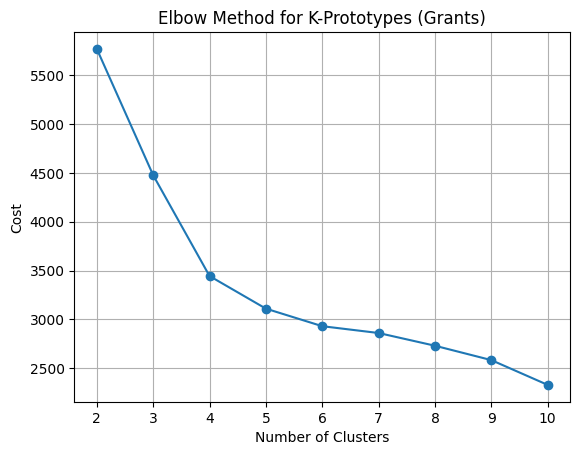

In [39]:
from kmodes.kprototypes import KPrototypes
import matplotlib.pyplot as plt

costs = []

categorical_cols = list(range(2, df_cluster.shape[1]))

for k in range(2, 11):
    kproto = KPrototypes(
        n_clusters=k,
        init='Cao',
        n_init=5,
        verbose=0,
        random_state=42
    )

    clusters = kproto.fit_predict(
        df_cluster,
        categorical=categorical_cols
    )

    costs.append(kproto.cost_)

plt.plot(range(2, 11), costs, marker='o')
plt.title("Elbow Method for K-Prototypes (Grants)")
plt.xlabel("Number of Clusters")
plt.ylabel("Cost")
plt.grid(True)
plt.show()


**Analysis:** With keeping NAs as zeros and using k-prototypes, k=4 clusters looks to be optimal.

K-prototypes uses .cost_ to find an elbow, and I see that k=4 produces an elbow, so I am going to try out k=4.

Silhouette score does not work  well with k-prototypes, because it expects numeric distances. K-prototypes uses euclidean (numeric) and matching dissimilarity (categorical). There is no built-in silhouette metric for mixed distance, so I will focus on this elbow plot above to choose my # clusters.

### **4. Run Clustering**

In [40]:
from kmodes.kprototypes import KPrototypes

# First two columns are numeric (funding, year)
categorical_cols = list(range(2, df_cluster.shape[1]))

kproto = KPrototypes(
    n_clusters=4,
    init='Cao', # This method initializes the centroids based on a distance and density-based approach, rather than picking random data points
    n_init=5,
    verbose=2,
    random_state=42
)

clusters = kproto.fit_predict(
    df_cluster,
    categorical=categorical_cols
)

df_cluster['cluster'] = clusters

Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 116, ncost: 4604.051319851276
Run: 1, iteration: 2/100, moves: 16, ncost: 4592.3120958834215
Run: 1, iteration: 3/100, moves: 5, ncost: 4591.46820059398
Run: 1, iteration: 4/100, moves: 4, ncost: 4590.777922709327
Run: 1, iteration: 5/100, moves: 5, ncost: 4590.498718307751
Run: 1, iteration: 6/100, moves: 25, ncost: 4493.639966865642
Run: 1, iteration: 7/100, moves: 247, ncost: 3853.5314867939337
Run: 1, iteration: 8/100, moves: 154, ncost: 3461.7885524459443
Run: 1, iteration: 9/100, moves: 5, ncost: 3460.959783800183
Run: 1, iteration: 10/100, moves: 1, ncost: 3460.9086494485755
Run: 1, iteration: 11/100, moves: 0, ncost: 3460.9086494485755
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 2, iteration: 1/100, moves: 803, ncost: 3487.1990978685767
Run: 2, iterati

In [41]:
import numpy as np
import pandas as pd

# --- STEP 1: CREATE A READABLE VERSION OF DATA ---
df_readable = df_cluster.copy()

# Reverse scaling and log math to get real numbers
df_readable[['estimated_funding', 'posted_year']] = scaler.inverse_transform(
    df_readable[['estimated_funding', 'posted_year']]
)
df_readable['estimated_funding'] = np.expm1(df_readable['estimated_funding'])

# Define our column lists
eligibility_cols = [col for col in df_readable.columns if col.startswith('eligibility_')]
category_cols = [col for col in df_readable.columns if col.startswith('category_')]

# --- STEP 2: DISCOVER THE CLUSTERS ---
for i in range(4):
    print("\n" + "="*60)
    print(f"               CLUSTER {i} ANALYSIS")
    print("="*60)

    c_data = df_readable[df_readable['cluster'] == i]
    total = len(c_data)

    # A. Stats & Funding
    print(f"Total Grants:   {total}")
    # NEW: Added Earliest and Latest year here
    print(f"Typical Year:   {int(c_data['posted_year'].median())}")
    print(f"Year Range:     {int(c_data['posted_year'].min())} to {int(c_data['posted_year'].max())}")
    print(f"Median Funding: ${c_data['estimated_funding'].median():,.2f}")
    print(f"Average Funding: ${c_data['estimated_funding'].mean():,.2f}")

    # B. Top 3 Agencies
    print("\nTop 3 Agencies:")
    agencies = c_data['agency_simplified'].value_counts().head(3)
    for name, count in agencies.items():
        print(f"  - {name}: {count} grants")

    # C. Top 3 Eligibility Types
    print("\nTop 3 Eligibility Types:")
    elig_counts = (c_data[eligibility_cols] == 'True').sum().sort_values(ascending=False).head(3)
    for col_name, count in elig_counts.items():
        clean_name = col_name.replace('eligibility_', '').replace('_', ' ')
        pct = (count / total) * 100
        print(f"  - {clean_name}: {int(pct)}% of cluster")

    # D. Top 3 Categories
    print("\nTop 3 Categories:")
    cat_counts = (c_data[category_cols] == 'True').sum().sort_values(ascending=False).head(3)
    for col_name, count in cat_counts.items():
        clean_name = col_name.replace('category_', '').replace('_', ' ')
        pct = (count / total) * 100
        print(f"  - {clean_name}: {int(pct)}% of cluster")


               CLUSTER 0 ANALYSIS
Total Grants:   956
Typical Year:   2022
Year Range:     2018 to 2023
Median Funding: $0.00
Average Funding: $1,286,369.25

Top 3 Agencies:
  - National Institutes of Health: 861 grants
  - Other: 47 grants
  - Centers for Disease Control and Prevention - ERA: 21 grants

Top 3 Eligibility Types:
  - state governments: 100% of cluster
  - independent school districts: 100% of cluster
  - county governments: 100% of cluster

Top 3 Categories:
  - health: 94% of cluster
  - education: 40% of cluster
  - income security: 16% of cluster

               CLUSTER 1 ANALYSIS
Total Grants:   81
Typical Year:   2014
Year Range:     2004 to 2018
Median Funding: $20,000.00
Average Funding: $80,575,163.70

Top 3 Agencies:
  - Other: 46 grants
  - National Science Foundation: 23 grants
  - Agency for International Development: 10 grants

Top 3 Eligibility Types:
  - others: 45% of cluster
  - unrestricted: 40% of cluster
  - nonprofits 501c3: 9% of cluster

Top 3 Ca

For the k-prototypes analysis (k=4), four distinct grant archetypes emerged:

**Cluster 0: The Modern Healthcare & Institutional Infrastructure Era (2018–2023).** This is the largest cluster **(956 grants)**, heavily concentrated in 2022 and dominated by the NIH (861 grants), with some CDC. The average award is over 1.2M dollars, which looks to be skewed up by some high amounts as the median is 0. It is defined by 100% eligibility for state and county governments and is overwhelmingly focused on Health (94%) and Education (40%), marking a highly specialized era of modern social infrastructure.

**Cluster 1: The Pre-Expansion Historical Baseline (2004–2018).** Representing an earlier era with a "typical year" of 2014, this smaller cluster **(81 grants)** reflects a more fragmented funding landscape. Interestingly, it features a massive average funding amount (80.5M) contrasted against a tiny 20k median, indicating a few extreme "mega-grants" among many small ones. Science (40%) is the lead category, but "Other" categories are high (22%), showing less thematic specialization than modern clusters.

**Cluster 2: High-Investment Science & STEM Innovation (2018–2023).** This cluster **(559 grants)** represents the "heavy hitters" of modern federal research, with a typical year of 2023 and a massive median funding of 10,000,000 dollars. Driven by the NSF (National Science Foundation) and the Department of the Army, it focuses primarily on Science (52%) and Environment (12%). It is characterized by high funding, reflecting large-scale federal investment in STEM and national security innovation.

**Cluster 3: Modern Non-Established-Funding Initiatives (2018–2023).** With **404 grants** and a typical year of 2023, this cluster is unique for having 0 dollars in both median and average funding, the grants that have "$0" or NA entered in estimated_funding, meaning grants in earlier development or without established/decided upon funding. At 404 grants, these are less so outliers and moreso a pattern to pay attention to. This cluster features a diverse mix of NIH, NASA, and "Other" agencies, with a blend of Science (39%) and Health (32%) categories, representing the diversification of federal grant formats in the current decade.

### **5. Deeper Analysis of Chosen k=4 Clusters**

*Changes since M2: I will go ahead with k=4 clusters using k-prototype in M3, based on this updated synergy and discovery that not dropping NAs is valuable (informed by the group)*

**Pairplot**

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

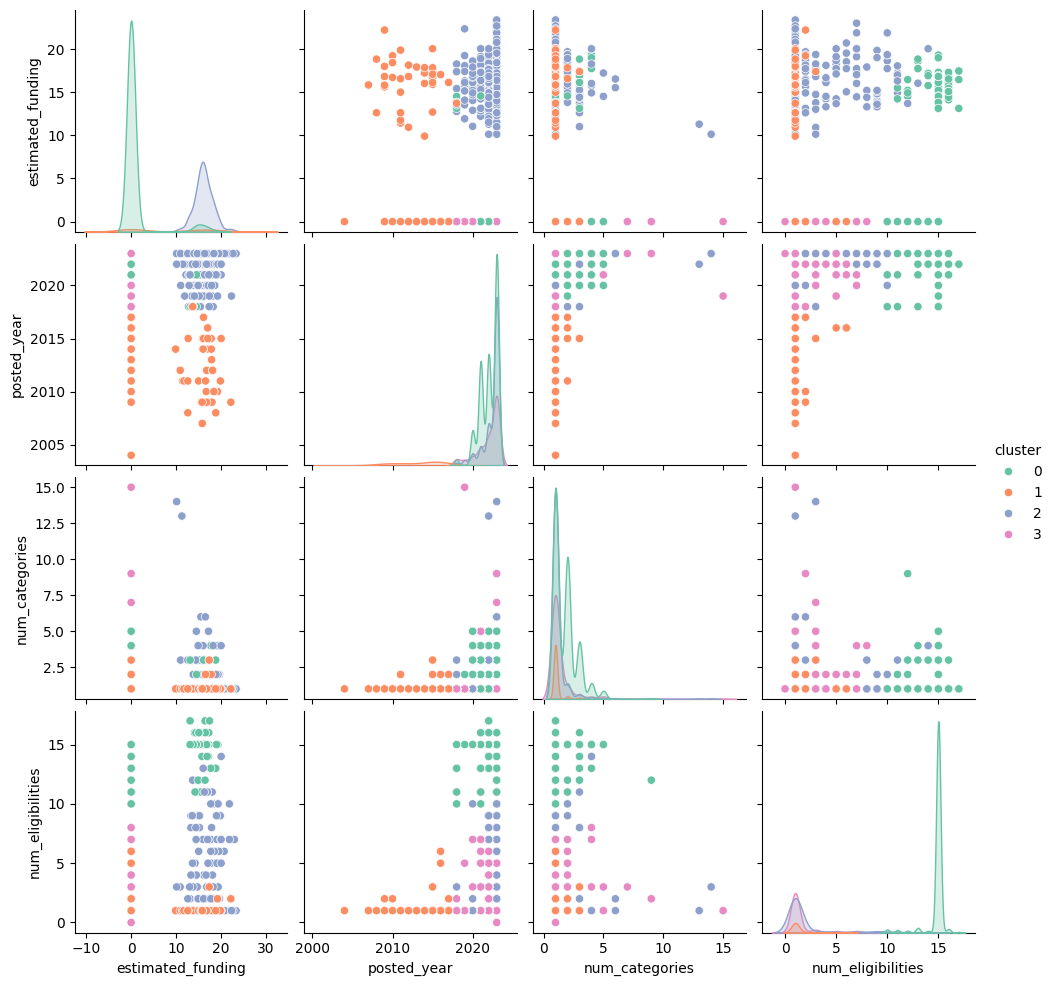

In [44]:
# Create the copy
df_plot = df_cluster.copy()

# Fix the Standardization (turning back into readable numbers)
df_plot[['estimated_funding', 'posted_year']] = scaler.inverse_transform(df_plot[['estimated_funding', 'posted_year']])

# Create the missing columns by counting 'True' strings
# Search for the columns and count how many times 'True' appears in each row
elig_cols = [col for col in df_plot.columns if col.startswith('eligibility_')]
cat_cols = [col for col in df_plot.columns if col.startswith('category_') and col != 'category_explanation']

df_plot['num_eligibilities'] = (df_plot[elig_cols] == 'True').sum(axis=1)
df_plot['num_categories'] = (df_plot[cat_cols] == 'True').sum(axis=1)

sns.pairplot(df_plot[['estimated_funding', 'posted_year', 'num_categories', 'num_eligibilities', 'cluster']],
             hue="cluster",
             palette="Set2")

plt.show()

**Further insights into my clusters based on pairplot:**

**Cluster 0: The Modern Healthcare & Institutional Infrastructure Era (2018–2023).** Low to medium estimated funding- with some higher outliers, recent years, 0-5 number of categories typically with some reaching 10, high number of eligibilities hovering around 15.

**Cluster 1: The Pre-Expansion Historical Baseline (2004–2018).** Smallest cluster, wide array of estimated funding, earlier years, on the smaller end of number of categories/eligibilities.

**Cluster 2: High-Investment Science & STEM Innovation (2018–2023).** High estimated funding, recent modern years, low number of categories/eligibilities.

**Cluster 3: Modern Non-Established-Funding Initiatives (2018–2023).** No estimated funding, more recent years, low number of categories/eligibilities.

**Boxplots**

**Estimated Funding by Cluster**

In [45]:
df_plot = df_cluster.copy()
df_plot[['estimated_funding', 'posted_year']] = scaler.inverse_transform(
    df_plot[['estimated_funding', 'posted_year']])

/tmp/ipython-input-919903924.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='cluster', y='estimated_funding', palette='Set2')


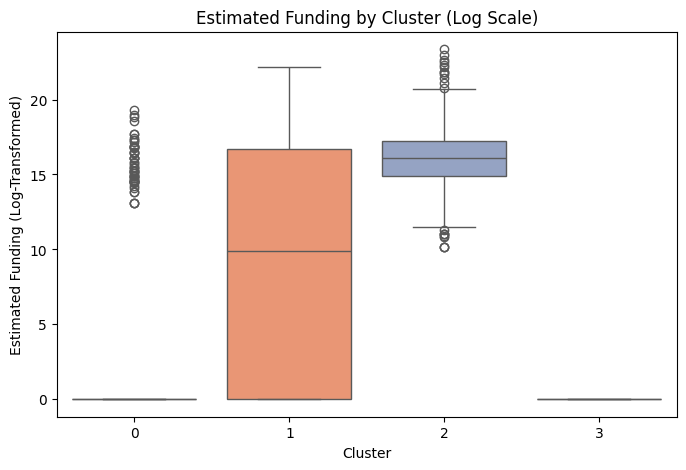

In [46]:
# Boxplot for Funding (Log Scale)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_plot, x='cluster', y='estimated_funding', palette='Set2')
plt.title('Estimated Funding by Cluster (Log Scale)')
plt.xlabel('Cluster')
plt.ylabel('Estimated Funding (Log-Transformed)')
plt.show()

**Analysis:** Cluster 2 represents a high-investment tier with a significantly higher median and a tight concentration of large-scale awards. Cluster 1 has the widest variety of funding amounts, spanning from small grants to large grants. Cluster 0 has low estimated funding but some outliers. Cluster 3 has 0 dollars in estimated funding.

**Posted Year by Cluster**

/tmp/ipython-input-4258542784.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='cluster', y='posted_year', palette='Set2')


Text(0, 0.5, 'Year')

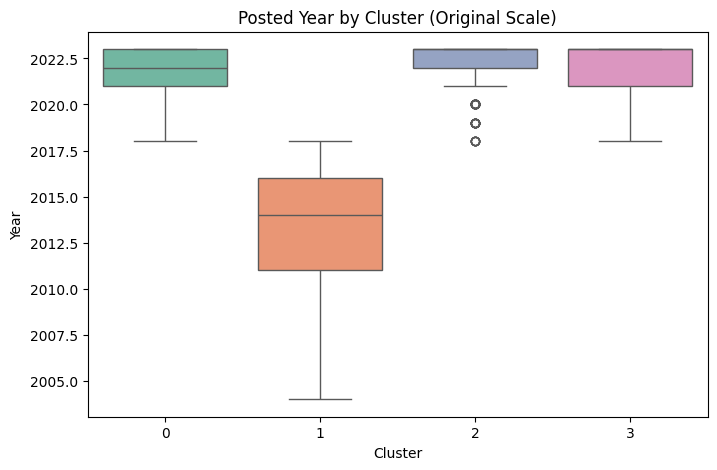

In [47]:
# Boxplot for Posted Year (Actual Years)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_plot, x='cluster', y='posted_year', palette='Set2')
plt.title('Posted Year by Cluster (Original Scale)')
plt.xlabel('Cluster')
plt.ylabel('Year')

**Analysis:** This year boxplot visually confirms my "Era" theory, showing a clear chronological split between the Cluster 1 historical baseline and the more recent activity in other clusters. While Cluster 1 covers a broad range centered around 2014, Clusters 0, 2, and 3 are tightly packed into the 2020s, illustrating a massive modern surge in federal grantmaking specialization (at least, whats tracked into the table). Unfortunately, clusters 0, 2, and 3 are not as differentiated by time as I initially hoped.

**Final overarching analysis:** Ultimately, some "era" clusters did come about from unsupervised machine learning clustering using k-prototypes. One older cluster and three more modern clusters formed. These also had some unique policy priorities. The largest cluster (0) encapsulates health and social infrastructure, Cluster 1 involves an earlier era (2004 to 2018) of more fragmented funding (at least what was tracked into the dataset), Cluster 2 involves high-investment science and military, and Cluster 3 showcases a variety of agencies including "other" (less common ones), NIH, and NASA grants without established grant funding amounts ("\$0").

Relating to COVID, 2020-time was a clear inflection point when federal grant-making exploded (at least, what was tracked in the Details/Merged table, but this is also reflected in the large Grants funding graph in EDA 2.2 in M2). This is especially the case for health, but also broadly across science, education, and environment. My clustering captured this, with the public health (NIH, CDC)-focused cluster (Cluster 0) likely playing a major part in the pandemic response era .

Federal agencies and policy analysts can see how these three clusters correlate to past efficacy, and economic and political trends. For instance, should another health crisis like COVID occur, how can they better allocate funds to lessen health and economic damages? Grant applicants can also use these clusters to make predictive analyses of future funding potential. More data over a longer period of time would be optimal to improve my "era" analysis.

##**M3 Further Integrations with Team**

The first two updated "synergies" between my team-- choosing to turn NAs into 0s rather than drop them to allow for a more complete data clustering story **and** using k-prototypes-- is above. Here is a continuation of group-informed analysis with each teammate's clustering.

###**1. Combining with further insights on grant descriptions (Maggie Croghan's ML)**

Maggie's clustering set to answer: How can clustering **grant descriptions** uncover meaningful **sub-topic categories** beyond broad classifications, and what do these finer-grained categories reveal about patterns of funding concentration, gaps, and potentially underserved areas within the grant landscape?

**1.1 Health Sub-Topics**

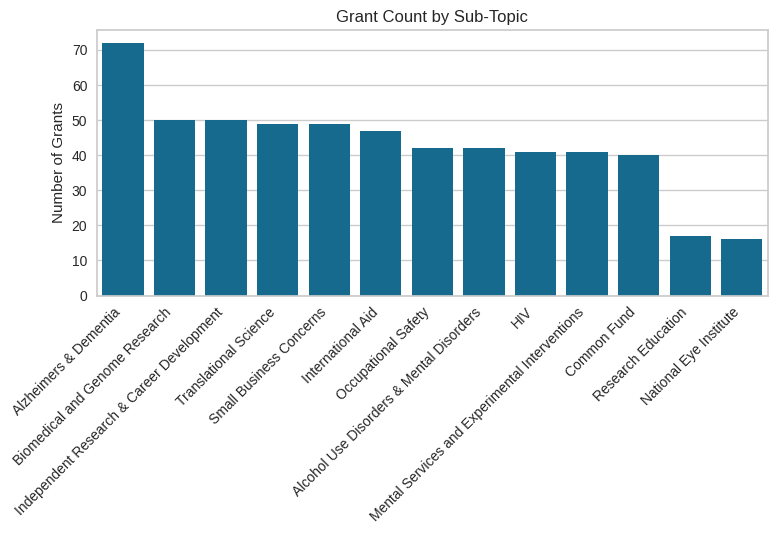

These health sub-topics can inform more details about my clustering, specifically about my health-centric Cluster 0: The Modern Healthcare & Institutional Infrastructure Era (2018–2023). This was my largest cluster, and is overwhelmingly driven by NIH- National Institutes of Health, with some CDC (Center for Disease Control). Maggie's model allows me to see the more in-depth descriptions tied to this cluster.

**1.2 Science Sub-Topics**

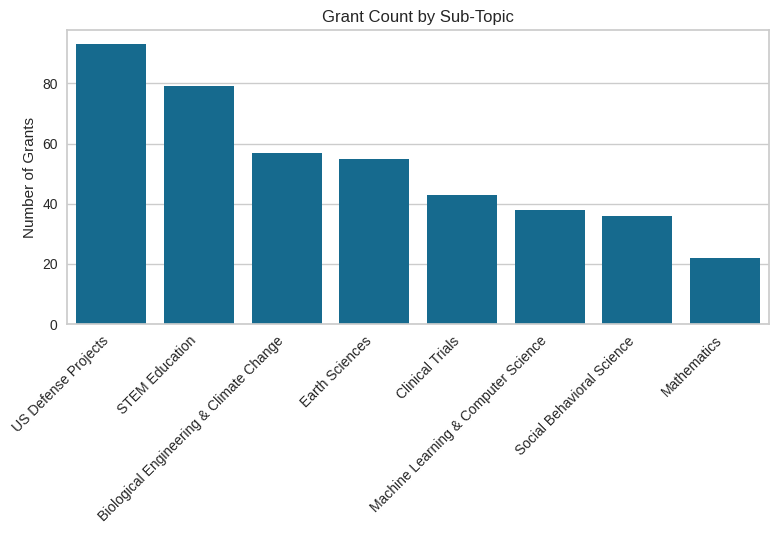

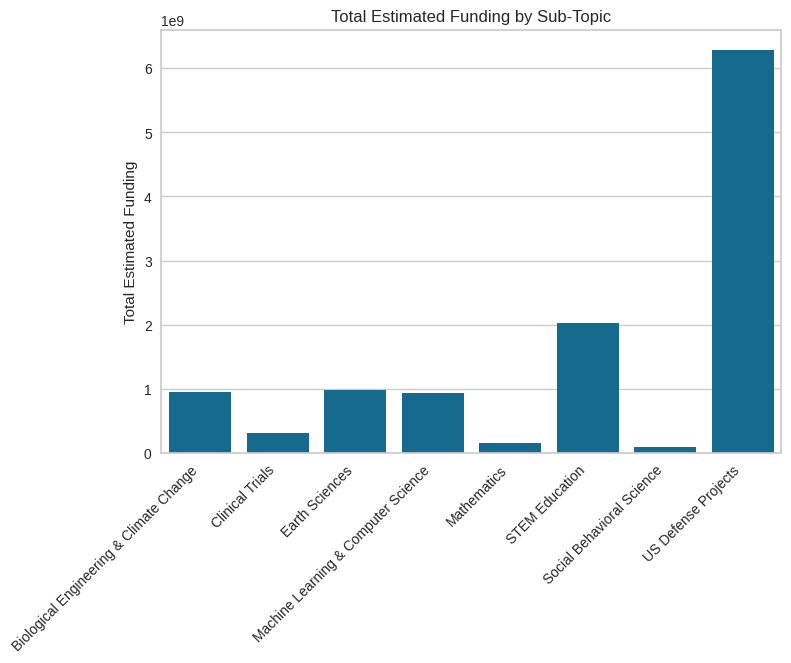

Maggie's in-depth analysis of the science-related grants informs my Cluster 2: High-Investment Science & STEM Innovation (2018–2023). The main agencies involved here are National Science Foundation and the US Army, which makes complete sense when looking at the descriptions. Interestingly, US Defense projects make up the highest-funded sub-topic in her "science" group, so it is not a surprise that this is my highest-average estimated funding cluster.

**1.3 Education Sub-Topics- Funding**

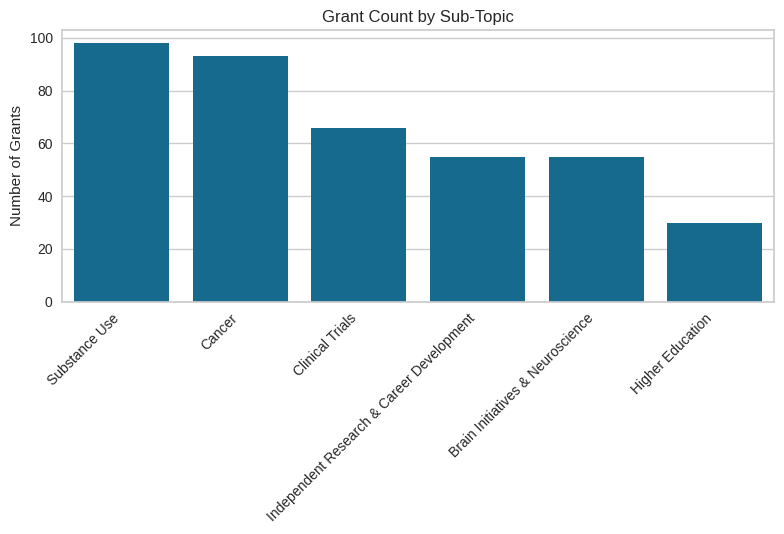

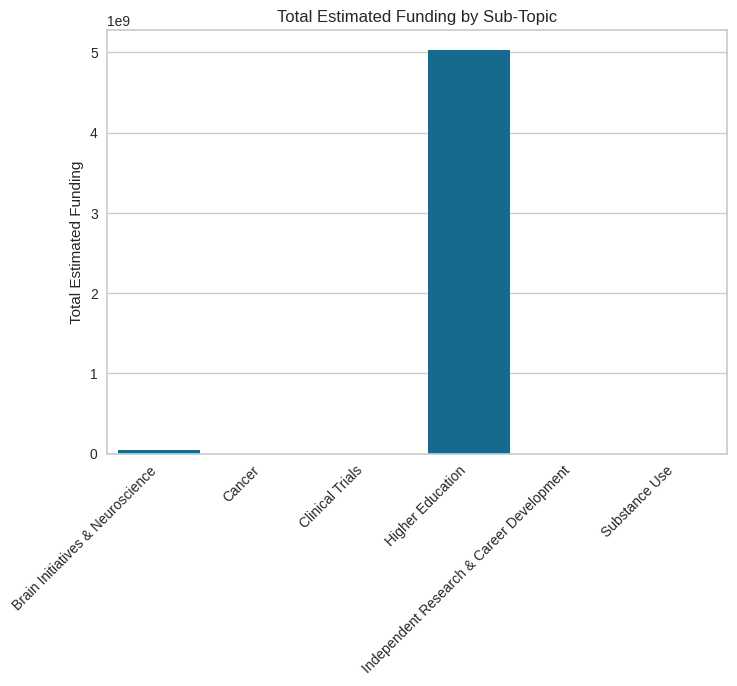

My clusters 0, 1, and and 3 involve the "education" category, which Maggie also dove into. These were lower in estimated funding than the other cluster (2) which aligns with what Maggie seems to have found with only "higher education" showing a significant amount of funds vs other education categories.

**Summary of findings ties to Maggie's insights:**

- Maggie’s bar charts on funding distribution highlight a significant volume of low-to-zero dollar awards. This directly informs my **Cluster 3: Modern Non-Established-Funding Initiatives (2018–2023)**, confirming that this cluster is characterized by opportunities where financial scope is not yet defined. As this cluster is 404 grants, this is not an outlier but a trend to note.

- My next lowest-estimated funding **Cluster 0: The Modern Healthcare & Institutional Infrastructure Era (2018–2023)**, is also informed by Maggie's bar charts. This cluster is 40% "education," which Maggie's chart shows has many 0s in estimated funding.

- Maggie's identification of high-funding agencies- like US Defense- perfectly mirrors my **Cluster 2: High-Investment Science & STEM Innovation (2018-2023)**, validating that agencies like this drive high-ceiling funds in our modern era.

###**2. Combining with further insights on eligibility clusters (Sambisha Godi's ML)**

Sambisha's clustering set to answer: Are there recurring **eligibility “archetypes”** among grant opportunities (government-only, nonprofit-focused, mixed eligibility), and how do these archetypes differ in funding and agency sponsorship?

Sambisha's coding with K‑Modes centroids reveal three distinct eligibility archetypes (these descriptions come from her colab file):

**Cluster 0: Broad Institutional Eligibility** — nearly all organizational eligibility types are marked as eligible, indicating grants designed for a wide range of institutions (governments, nonprofits, universities, businesses, and tribal entities).

**Cluster 1: Minimal/Unspecified Eligibility** — only the “others” flag is true, suggesting grants with limited or unclear eligibility criteria.

**Cluster 2: Fully Unrestricted Eligibility** — only the unrestricted flag is true, representing grants open to any applicant. These patterns confirm that eligibility criteria naturally group into meaningful archetypes, providing a strong foundation for comparing clusters on funding and agency sponsorship.

To see how my clusters correlate with Sambisha's findings, I will create a heatmap. A heatmap will show me the "concentration" of each eligibility type across my clusters. If a cluster has dark squares across many rows, it matches her "Broad Institutional" type. If it only has one dark square for "others," it matches her "Minimal" type.

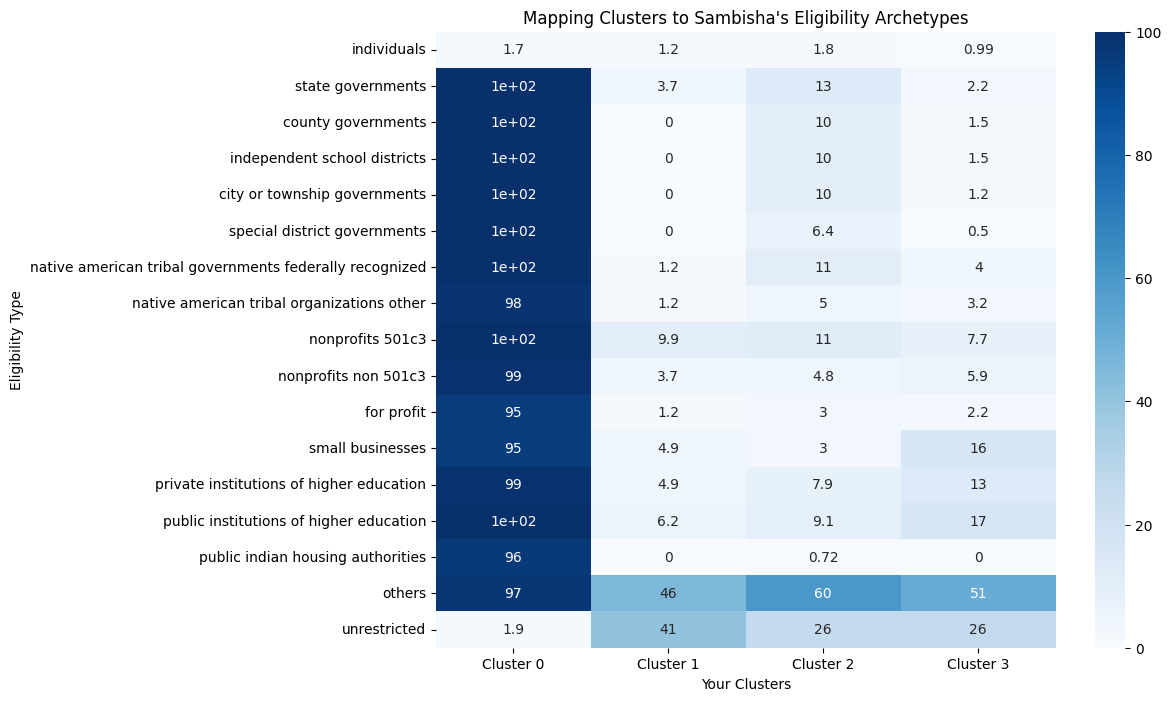

In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Get the list of all eligibility columns
elig_cols = [col for col in df_cluster.columns if col.startswith('eligibility_')]

# Create an empty table (DataFrame) to hold percentages
elig_profile = pd.DataFrame()

for i in range(4):
    # Filter the data to just this cluster
    cluster_subset = df_cluster[df_cluster['cluster'] == i]

    # Calculate the percentage of 'True' for each column
    # (True counts as 1, False as 0, so the mean * 100 = Percentage)
    cluster_percentages = (cluster_subset[elig_cols] == 'True').mean() * 100

    # Add this result to our table as a new column
    elig_profile[f'Cluster {i}'] = cluster_percentages

# Clean up the row names (removing the 'eligibility_' prefix)
elig_profile.index = [name.replace('eligibility_', '').replace('_', ' ') for name in elig_profile.index]

# Create the Heatmap
plt.figure(figsize=(10, 8))

# annot=True: This puts the actual numbers inside the squares
# cmap='Blues': A simple color theme (Darker blue = higher percentage)
sns.heatmap(elig_profile, annot=True, cmap='Blues')

plt.title("Mapping Clusters to Sambisha's Eligibility Archetypes")
plt.xlabel("Your Clusters")
plt.ylabel("Eligibility Type")
plt.show()

**Summary of findings ties to Sambisha's insights:**

My **Cluster 0: The Modern Healthcare & Institutional Infrastructure Era (2018–2023)** clearly fits within Sambisha's **Broad Institutional Eligibility** cluster-- with many eligibilities checked off. This cluster is concentrated with NIH grants-- health-focused. This finding adds up because on my pairplot, this cluster 0 had a high count of eligibilities!

My other 3 clusters fit moreso within a mix of Sambisha's Cluster 1: Minimal/Unspecified Eligibility and Cluster 2: Fully Unrestricted Eligibility-- not as clear of a definitive aligning pattern here.

###**3. Combining with further insights on grant agency clusters (Allison Kramer's ML)**

Allison's clustering set to answer: What underlying patterns emerge in how **federal agencies** structure and distribute **grant funding**?

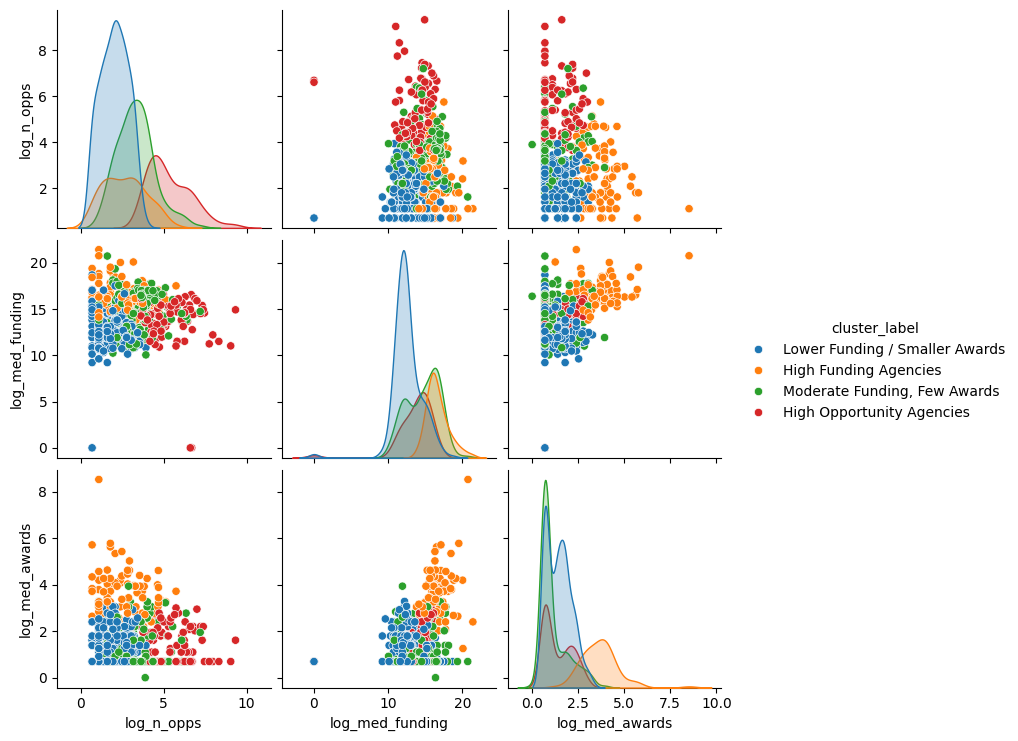

**Exploring "expected number of awards" within my own clusters**

Note that my clusters only use the merged table, with only 2000 rows (and some missing) vs Allison's more expansive Grants table.

In [49]:
# Convert the column to numeric numbers
# 'coerce' turns any weird text into 'NA' (missing) so it doesn't break the math
merged['expected_awards_numeric'] = pd.to_numeric(merged['expected_number_of_awards_x'], errors='coerce')

# Add the cluster labels to df
# (Assuming your clusters are stored in df_cluster['cluster'])
merged['cluster'] = df_cluster['cluster'].values

# Calculate Mean and Median grouped by Cluster
award_stats = merged.groupby('cluster')['expected_awards_numeric'].agg(['mean', 'median', 'count'])

# Display the results
print("Expected Number of Awards by Cluster:")
print(award_stats)

Expected Number of Awards by Cluster:
                 mean  median  count
cluster                             
0           86.302326    10.0     43
1           36.604167     1.0     48
2           79.479167    15.0    432
3        10500.333333     3.0     96


**Summary of findings ties to Allison's insights:**

Allison's cluster **lower funding/smaller awards** reminds me of my **Cluster 3: Modern Non-Established-Funding Initiatives (2018–2023)** with no listed estimated funding. But, in my expected awards count, this cluster actually has some high expected awards (mean skewed up from some larger one(s)). Therefore, our clusters are not fully overlapping.

Her cluster **high funding agencies** reminds me of my **Cluster 2: High-Investment Science & STEM Innovation (2018–2023)**, with the highest estimated funding (mainly National Science Foundation and US Army, and "other"). Both of our clusters are also high in terms of number of awards.

**Final analysis:** With the combination of our 4 team members' clusters, I now have an even clearer understanding of the temporal eras that have emerged.

By integrating the team's multi-faceted findings with my temporal archetypes, it is clear that recent grantmaking is defined by a shift toward specialized, high-investment science and broad-eligibility healthcare initiatives. Maggie’s and Allison’s insights confirm that while agencies like the NSF and US Army drive high-funding "High-Investment Science & STEM" eras (Cluster 2), a significant trend in the "Modern Non-Established-Funding" era (Cluster 3) involves zero dollar estimated funding awards where financial scope remains undefined.

Furthermore, the alignment between my "Modern Healthcare" archetype (Cluster 0) and Sambisha’s finding of high eligibility counts validates that contemporary healthcare and infrastructure grants are increasingly characterized by broad institutional access.

My Cluster 1, representing years 2004-2018, is less easy to interpret against my teammates' clusters as I was the only one that segmented on time (years). This is more of a broad cluster of a mix of qualities in earlier years- but its wide range of funding amounts can be tied to multiple of Allison's clusters.

**AI Disclosure:** Our written M3 report includes a link to my conversations with AI chatbots Claude and Gemini, which helped me figure out k-prototype strategies, optimal code for k-prototype clustering, as well as analyzing some findings and ways to link my findings with those of my teammates.